#인공지능개론 5주차 과제

###컴퓨터공학과 202337644 김태규
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/diabetes.csv')
df = df.dropna()

# 피처(X)와 타겟(y) 분리
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values
Y = pd.get_dummies(y).values  # 원-핫 인코딩

# 데이터 분할 및 스케일링
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 모델 설계
model = Sequential([
    Dense(16, input_shape=(X_train.shape[1],), activation='relu'),
    Dense(8, activation='relu'),
    Dense(2, activation='softmax')  # 0 또는 1이므로 출력 노드 2개
])

# 컴파일 및 학습
model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=50, batch_size=10, validation_data=(X_test, y_test), verbose=1)

# 평가
from sklearn.metrics import classification_report
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true, y_pred))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7215 - loss: 0.5406 - val_accuracy: 0.8182 - val_loss: 0.4417
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7671 - loss: 0.4817 - val_accuracy: 0.8182 - val_loss: 0.4430
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7687 - loss: 0.4615 - val_accuracy: 0.8052 - val_loss: 0.4437
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7752 - loss: 0.4577 - val_accuracy: 0.7857 - val_loss: 0.4727
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7834 - loss: 0.4455 - val_accuracy: 0.7662 - val_loss: 0.4681
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7932 - loss: 0.4501 - val_accuracy: 0.7532 - val_loss: 0.4613
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7850 - loss: 0.4347 - val_accuracy: 0.7792 - val_loss: 0.5045
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7997 - loss: 0.4373 - val_accuracy: 0.7662 - val_loss

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 8953.4531 - mae: 82.9333 - val_loss: 1473.3086 - val_mae: 29.0597
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1152.2522 - mae: 25.9898 - val_loss: 972.8541 - val_mae: 23.6121
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 863.4205 - mae: 22.6843 - val_loss: 860.0547 - val_mae: 22.2912
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 787.9971 - mae: 21.6624 - val_loss: 939.3054 - val_mae: 23.9060
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 735.2845 - mae: 20.6981 - val_loss: 742.2357 - val_mae: 21.0942
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 689.3834 - mae: 20.1767 - val_loss: 740.8022 - val_mae: 20.5166
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 673.1116 - mae: 19.7653 - val_loss: 734.1088 - val_mae: 20.7335
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 676.4957 - mae: 19.7638 - val_loss: 764.8793 - val_mae: 20.9960
Epoch 9/1

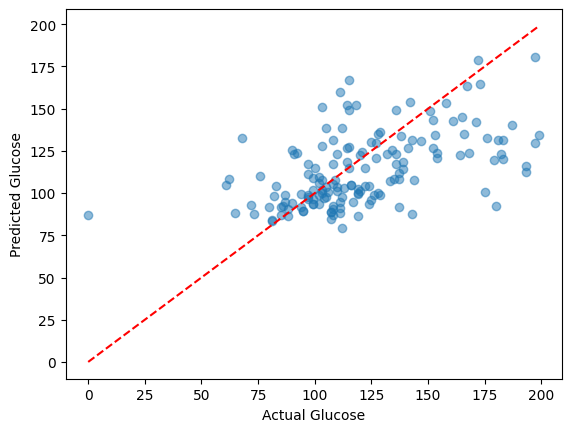

In [2]:
# 피처(X)와 타겟(y) 분리
X_reg = df.drop('Glucose', axis=1).values
y_reg = df['Glucose'].values

# 데이터 분할 및 스케일링
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=0)
scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)

# 모델 설계
model_reg = Sequential([
    Dense(32, input_shape=(X_train_reg.shape[1],), activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)  # 수치를 그대로 출력해야 하므로 마지막 층은 노드 1개
])

# 컴파일 및 학습 (회귀용 MSE 손실함수 사용)
model_reg.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])
model_reg.fit(X_train_reg, y_train_reg, epochs=100, batch_size=10, validation_data=(X_test_reg, y_test_reg), verbose=1)

# 예측 결과 시각화
y_pred_reg = model_reg.predict(X_test_reg).flatten()
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel('Actual Glucose')
plt.ylabel('Predicted Glucose')
plt.show()